In [1]:
import sys
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import StructType,StructField,StringType,IntegerType,DoubleType

spark = (SparkSession.builder
         .appName("check-python")
         .master("local[*]")
         .config("spark.pyspark.python", sys.executable)
         .config("spark.pyspark.driver.python", sys.executable)
         .getOrCreate())

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/02/27 09:15:43 WARN Utils: Your hostname, MacBook--Azich.local, resolves to a loopback address: 127.0.0.1; using 172.20.10.2 instead (on interface en0)
26/02/27 09:15:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/27 09:15:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


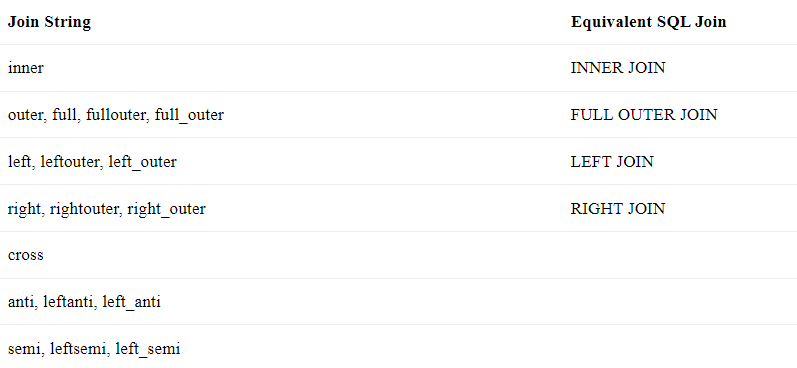

In [ ]:
emp = [(1,"Smith",-1,"2018","10","M",3000), \
    (2,"Rose",1,"2010","20","M",4000), \
    (3,"Williams",1,"2010","10","M",1000), \
    (4,"Jones",2,"2005","10","F",2000), \
    (5,"Brown",2,"2010","40","",-1), \
    (6,"Brown",2,"2010","50","",-1) \
  ]
empColumns = ["emp_id","name","superior_emp_id","year_joined", \
       "emp_dept_id","gender","salary"]

empDF = spark.createDataFrame(data=emp, schema=empColumns)
empDF.printSchema()
empDF.show(truncate=False)

dept = [("Finance",10), \
    ("Marketing",20), \
    ("Sales",30), \
    ("IT",40) \
  ]
deptColumns = ["dept_name","dept_id"]
deptDF = spark.createDataFrame(data=dept, schema=deptColumns)
deptDF.printSchema()
deptDF.show(truncate=False)

root
 |-- emp_id: long (nullable = true)
 |-- name: string (nullable = true)
 |-- superior_emp_id: long (nullable = true)
 |-- year_joined: string (nullable = true)
 |-- emp_dept_id: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- salary: long (nullable = true)



+------+--------+---------------+-----------+-----------+------+------+
|emp_id|name    |superior_emp_id|year_joined|emp_dept_id|gender|salary|
+------+--------+---------------+-----------+-----------+------+------+
|1     |Smith   |-1             |2018       |10         |M     |3000  |
|2     |Rose    |1              |2010       |20         |M     |4000  |
|3     |Williams|1              |2010       |10         |M     |1000  |
|4     |Jones   |2              |2005       |10         |F     |2000  |
|5     |Brown   |2              |2010       |40         |      |-1    |
|6     |Brown   |2              |2010       |50         |      |-1    |
+------+--------+---------------+-----------+-----------+------+------+

root
 |-- dept_name: string (nullable = true)
 |-- dept_id: long (nullable = true)

+---------+-------+
|dept_name|dept_id|
+---------+-------+
|Finance  |10     |
|Marketing|20     |
|Sales    |30     |
|IT       |40     |
+---------+-------+



* Inner Join: Возвращает только строки с совпадающими ключами в обоих DataFrames.

* Left Join: Возвращает все строки из левого DataFrame и совпадающие строки из правого DataFrame.

* Right Join: Возвращает все строки из правого DataFrame и совпадающие строки из левого DataFrame.

* Full Outer Join: Возвращает все строки из обоих фреймов данных, включая совпадающие и не совпадающие строки.

* Left Semi Join: Возвращает все строки из левого фрейма данных, для которых есть совпадение в правом фрейме данных.

* Left Anti Join: Возвращает все строки из левого DataFrame, в которых нет совпадений с правым DataFrame. По аналогии Right Anti Join etc.

In [ ]:
# Inner join
empDF.join(deptDF,
           on=[empDF.emp_dept_id==deptDF.dept_id],
           how="inner") \
            .show(truncate=False)

+------+--------+---------------+-----------+-----------+------+------+---------+-------+
|emp_id|name    |superior_emp_id|year_joined|emp_dept_id|gender|salary|dept_name|dept_id|
+------+--------+---------------+-----------+-----------+------+------+---------+-------+
|1     |Smith   |-1             |2018       |10         |M     |3000  |Finance  |10     |
|3     |Williams|1              |2010       |10         |M     |1000  |Finance  |10     |
|4     |Jones   |2              |2005       |10         |F     |2000  |Finance  |10     |
|2     |Rose    |1              |2010       |20         |M     |4000  |Marketing|20     |
|5     |Brown   |2              |2010       |40         |      |-1    |IT       |40     |
+------+--------+---------------+-----------+-----------+------+------+---------+-------+



In [4]:
# Left outer join
empDF.join(deptDF,
           on=[empDF.emp_dept_id ==  deptDF.dept_id],
           how="left") \
    .show(truncate=False)

empDF.join(deptDF,
           on=[empDF.emp_dept_id ==  deptDF.dept_id],
           how="leftouter") \
    .show(truncate=False)

+------+--------+---------------+-----------+-----------+------+------+---------+-------+
|emp_id|name    |superior_emp_id|year_joined|emp_dept_id|gender|salary|dept_name|dept_id|
+------+--------+---------------+-----------+-----------+------+------+---------+-------+
|1     |Smith   |-1             |2018       |10         |M     |3000  |Finance  |10     |
|2     |Rose    |1              |2010       |20         |M     |4000  |Marketing|20     |
|3     |Williams|1              |2010       |10         |M     |1000  |Finance  |10     |
|4     |Jones   |2              |2005       |10         |F     |2000  |Finance  |10     |
|5     |Brown   |2              |2010       |40         |      |-1    |IT       |40     |
|6     |Brown   |2              |2010       |50         |      |-1    |NULL     |NULL   |
+------+--------+---------------+-----------+-----------+------+------+---------+-------+

+------+--------+---------------+-----------+-----------+------+------+---------+-------+
|emp_id|n

Left Semi Join
---
Левое полусоединение в PySpark возвращает только те строки из левого DataFrame (первый DataFrame, упомянутый в операции соединения), в которых есть совпадение с правым DataFrame (вторым DataFrame). 

При этом в результирующий DataFrame не включаются столбцы из правого DataFrame. Этот тип соединения полезен, когда нужно отфильтровать только строки из левого DataFrame на основании того, есть ли у них совпадающий ключ в правом DataFrame.

Левое полусоединение также может быть достигнуто путем выбора только столбцов из левого набора данных из результата внутреннего соединения.

In [5]:
# Left semi join
empDF.join(deptDF,
           on=[empDF.emp_dept_id ==  deptDF.dept_id],
           how="leftsemi") \
   .show(truncate=False)

+------+--------+---------------+-----------+-----------+------+------+
|emp_id|name    |superior_emp_id|year_joined|emp_dept_id|gender|salary|
+------+--------+---------------+-----------+-----------+------+------+
|1     |Smith   |-1             |2018       |10         |M     |3000  |
|3     |Williams|1              |2010       |10         |M     |1000  |
|4     |Jones   |2              |2005       |10         |F     |2000  |
|2     |Rose    |1              |2010       |20         |M     |4000  |
|5     |Brown   |2              |2010       |40         |      |-1    |
+------+--------+---------------+-----------+-----------+------+------+



Left Anti Join
---
Левое антисоединение в PySpark возвращает только те строки из левого DataFrame (первый DataFrame, упомянутый в операции соединения), в которых нет совпадений с правым DataFrame (вторым DataFrame). 

Он исключает любые строки из левого DataFrame, которые имеют соответствующий ключ в правом DataFrame. 

Этот тип соединения полезен, когда необходимо отфильтровать строки из левого DataFrame, которые имеют совпадающие ключи в правом DataFrame.

In [6]:
# Left anti join
empDF.join(deptDF,
           on=[empDF.emp_dept_id ==  deptDF.dept_id],
           how="leftanti") \
   .show(truncate=False)

+------+-----+---------------+-----------+-----------+------+------+
|emp_id|name |superior_emp_id|year_joined|emp_dept_id|gender|salary|
+------+-----+---------------+-----------+-----------+------+------+
|6     |Brown|2              |2010       |50         |      |-1    |
+------+-----+---------------+-----------+-----------+------+------+



In [7]:
# Как избавиться от дублированных столбцов после присоединения в PySpark?
# Функция PySpark distinct() используется для удаления дубликатов строк (всех столбцов) из набора данных, 
# а функция dropDuplicates() используется для удаления строк на основе выбранных (одного или нескольких) столбцов.

union()
---
Метод union() DataFrame используется для объединения двух DataFrame с одинаковой структурой/схемой. На выходе получаются все строки из обоих DataFrame, а дубликаты сохраняются. Если схемы не совпадают, возвращается ошибка. Чтобы работать с DataFrame, обладающими разными схемами, необходимо использовать преобразование unionByName().

In [ ]:
# df 1 
simpleData = [("James","Sales","NY",90000,34,10000), \
    ("Michael","Sales","NY",86000,56,20000), \
    ("Robert","Sales","CA",81000,30,23000), \
    ("Maria","Finance","CA",90000,24,23000) \
  ]

columns= ["employee_name","department","state","salary","age","bonus"]
df = spark.createDataFrame(data = simpleData, schema = columns)
df.printSchema()
df.show(truncate=False)

root
 |-- employee_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- state: string (nullable = true)
 |-- salary: long (nullable = true)
 |-- age: long (nullable = true)
 |-- bonus: long (nullable = true)



+-------------+----------+-----+------+---+-----+
|employee_name|department|state|salary|age|bonus|
+-------------+----------+-----+------+---+-----+
|James        |Sales     |NY   |90000 |34 |10000|
|Michael      |Sales     |NY   |86000 |56 |20000|
|Robert       |Sales     |CA   |81000 |30 |23000|
|Maria        |Finance   |CA   |90000 |24 |23000|
+-------------+----------+-----+------+---+-----+



In [3]:
# df 2 
simpleData2 = [("James","Sales","NY",90000,34,10000), \
    ("Maria","Finance","CA",90000,24,23000), \
    ("Jen","Finance","NY",79000,53,15000), \
    ("Jeff","Marketing","CA",80000,25,18000), \
    ("Kumar","Marketing","NY",91000,50,21000) \
  ]

columns2= ["employee_name","department","state","salary","age","bonus"]
df2 = spark.createDataFrame(data = simpleData2, schema = columns2)
df2.printSchema()
df2.show(truncate=False)

root
 |-- employee_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- state: string (nullable = true)
 |-- salary: long (nullable = true)
 |-- age: long (nullable = true)
 |-- bonus: long (nullable = true)

+-------------+----------+-----+------+---+-----+
|employee_name|department|state|salary|age|bonus|
+-------------+----------+-----+------+---+-----+
|James        |Sales     |NY   |90000 |34 |10000|
|Maria        |Finance   |CA   |90000 |24 |23000|
|Jen          |Finance   |NY   |79000 |53 |15000|
|Jeff         |Marketing |CA   |80000 |25 |18000|
|Kumar        |Marketing |NY   |91000 |50 |21000|
+-------------+----------+-----+------+---+-----+



In [4]:
# union() to merge two DataFrames
uniondf = df.union(df2)
uniondf.show(truncate=False)

+-------------+----------+-----+------+---+-----+
|employee_name|department|state|salary|age|bonus|
+-------------+----------+-----+------+---+-----+
|James        |Sales     |NY   |90000 |34 |10000|
|Michael      |Sales     |NY   |86000 |56 |20000|
|Robert       |Sales     |CA   |81000 |30 |23000|
|Maria        |Finance   |CA   |90000 |24 |23000|
|James        |Sales     |NY   |90000 |34 |10000|
|Maria        |Finance   |CA   |90000 |24 |23000|
|Jen          |Finance   |NY   |79000 |53 |15000|
|Jeff         |Marketing |CA   |80000 |25 |18000|
|Kumar        |Marketing |NY   |91000 |50 |21000|
+-------------+----------+-----+------+---+-----+



Слияние без дубликатов.

Поскольку метод union() возвращает все строки, мы будем использовать функцию distinct(), чтобы вернуть только одну запись при наличии дубликата.

In [5]:
disdf = df.union(df2).distinct()
disdf.show(truncate=False)

+-------------+----------+-----+------+---+-----+
|employee_name|department|state|salary|age|bonus|
+-------------+----------+-----+------+---+-----+
|James        |Sales     |NY   |90000 |34 |10000|
|Michael      |Sales     |NY   |86000 |56 |20000|
|Robert       |Sales     |CA   |81000 |30 |23000|
|Maria        |Finance   |CA   |90000 |24 |23000|
|Jen          |Finance   |NY   |79000 |53 |15000|
|Jeff         |Marketing |CA   |80000 |25 |18000|
|Kumar        |Marketing |NY   |91000 |50 |21000|
+-------------+----------+-----+------+---+-----+



unionByname()
---

Функция unionByName() также предоставляет аргумент allowMissingColumns, чтобы указать, если у вас разные количества столбцов. 

Если вы используете более старую версию Spark 3.1, воспользуйтесь приведенным ниже подходом для объединения DataFrames с разными именами столбцов.

In [6]:
# df1
data = [("James",34), ("Michael",56), ("Robert",30), ("Maria",24) ]

df1 = spark.createDataFrame(data = data, schema=["name","id"])
df1.printSchema()

# df2 
data2=[(34,"James"), (45,"Maria"), (45,"Jen"),(34,"Jeff")]

df2 = spark.createDataFrame(data = data2, schema = ["id","name"])
df2.printSchema()

root
 |-- name: string (nullable = true)
 |-- id: long (nullable = true)

root
 |-- id: long (nullable = true)
 |-- name: string (nullable = true)



In [7]:
df3 = df1.unionByName(df2)
df3.printSchema()
df3.show()

root
 |-- name: string (nullable = true)
 |-- id: long (nullable = true)

+-------+---+
|   name| id|
+-------+---+
|  James| 34|
|Michael| 56|
| Robert| 30|
|  Maria| 24|
|  James| 34|
|  Maria| 45|
|    Jen| 45|
|   Jeff| 34|
+-------+---+



In [ ]:
# df 1
df1 = spark.createDataFrame([[5, 2, 6]], ["A", "B", "C"])
df2 = spark.createDataFrame([[6, 7, 3]], ["B", "C", "D"])

df1.show(truncate=False)
df2.show(truncate=False)

# union df 
df3 = df1.unionByName(df2, allowMissingColumns=True)
df3.show()
df3.printSchema()

+---+---+---+
|A  |B  |C  |
+---+---+---+
|5  |2  |6  |
+---+---+---+

+---+---+---+
|B  |C  |D  |
+---+---+---+
|6  |7  |3  |
+---+---+---+

+----+---+---+----+
|   A|  B|  C|   D|
+----+---+---+----+
|   5|  2|  6|NULL|
|NULL|  6|  7|   3|
+----+---+---+----+

root
 |-- A: long (nullable = true)
 |-- B: long (nullable = true)
 |-- C: long (nullable = true)
 |-- D: long (nullable = true)



26/02/28 01:39:45 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 403442 ms exceeds timeout 120000 ms
26/02/28 01:39:46 WARN SparkContext: Killing executors is not supported by current scheduler.
26/02/28 01:39:52 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$